<a href="https://colab.research.google.com/github/julipolovinkina-hub/OOP_2/blob/main/OOP_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# ЭТАП 1 и 2. Базовые классы и Наследование + Валидация
# ==========================================

class MenuItem:
    """Базовый класс для любой позиции в меню ресторана."""

    def __init__(self, name: str, price: float):
        if not isinstance(name, str) or not name.strip():
            raise ValueError("Название позиции должно быть непустой строкой.")
        if not isinstance(price, (int, float)) or price < 0:
            raise ValueError("Цена должна быть неотрицательным числом.")

        self.name = name.strip()
        self.price = float(price)

    def apply_discount(self, is_loyal: bool) -> float:
        """Полиморфный метод: базовая реализация (скидки нет)."""
        return 0.0

    def __str__(self) -> str:
        return f"{self.name} | Цена: {self.price:.2f} руб."


class Dish(MenuItem):
    """Класс блюда, наследуемый от MenuItem."""

    def __init__(self, name: str, price: float, ingredients: str):
        if not isinstance(ingredients, str) or not ingredients.strip():
            raise ValueError("Состав блюда должен быть непустой строкой.")

        # Вызов конструктора родительского класса (там тоже сработает валидация name и price)
        super().__init__(name, price)
        self.ingredients = ingredients.strip()

    def apply_discount(self, is_loyal: bool) -> float:
        """Переопределение: скидка 15% на блюда для держателей карт лояльности."""
        if is_loyal:
            return self.price * 0.15
        return 0.0

    def __str__(self) -> str:
        base_str = super().__str__()
        return f"{base_str} | Состав: {self.ingredients}"


class Drink(MenuItem):
    """Класс напитка, наследуемый от MenuItem."""

    def __init__(self, name: str, price: float, volume_ml: int):
        if not isinstance(volume_ml, int) or volume_ml <= 0:
            raise ValueError("Объем напитка должен быть положительным целым числом.")

        super().__init__(name, price)
        self.volume_ml = volume_ml

    def apply_discount(self, is_loyal: bool) -> float:
        """Переопределение: на напитки скидка не распространяется."""
        return 0.0

    def __str__(self) -> str:
        base_str = super().__str__()
        return f"{base_str} | Объем: {self.volume_ml} мл"


class Customer:
    """Базовый класс посетителя ресторана."""

    def __init__(self, name: str, table_number: int):
        if not isinstance(name, str) or not name.strip():
            raise ValueError("Имя гостя должно быть непустой строкой.")
        if not isinstance(table_number, int) or table_number <= 0:
            raise ValueError("Номер столика должен быть положительным целым числом.")

        self.name = name.strip()
        self.table_number = table_number

    @property
    def is_loyal(self) -> bool:
        """Свойство для полиморфной проверки статуса лояльности."""
        return False

    def __str__(self) -> str:
        return f"Гость: {self.name} | Столик: №{self.table_number}"


class LoyaltyCardHolder(Customer):
    """Класс гостя с картой лояльности, наследуемый от Customer."""

    def __init__(self, name: str, table_number: int, points: int):
        if not isinstance(points, int) or points < 0:
            raise ValueError("Баллы лояльности должны быть неотрицательным целым числом.")

        super().__init__(name, table_number)
        self.points = points

    @property
    def is_loyal(self) -> bool:
        """Переопределение свойства: гость является лояльным."""
        return True

    def __str__(self) -> str:
        base_str = super().__str__()
        return f"{base_str} | Баллы лояльности: {self.points}"


from typing import List

# ==========================================
# ЭТАПЫ 3 и 4. Класс-контейнер (Композиция) + Валидация
# ==========================================

class Check:
    """Класс чека, агрегирующий клиента и список заказанных позиций."""

    def __init__(self, customer: Customer):
        if not isinstance(customer, Customer):
            raise TypeError("Клиент должен быть объектом класса Customer или его наследником.")

        self.customer = customer
        self.items: List[MenuItem] = []

    def add_item(self, item: MenuItem) -> None:
        """Добавляет позицию меню в чек с проверкой типа."""
        if not isinstance(item, MenuItem):
            raise TypeError("Добавляемый элемент должен быть объектом класса MenuItem или его наследником.")
        self.items.append(item)

    def calculate_total(self) -> float:
        """Рассчитывает итоговую сумму чека с учетом полиморфных скидок."""
        total = 0.0
        is_loyal = self.customer.is_loyal

        for item in self.items:
            discount = item.apply_discount(is_loyal)
            final_price = item.price - discount
            total += final_price

        return total

    def get_detailed_report(self) -> str:
        """Возвращает детализированный отчет по чеку."""
        report = [f"ЧЕК для: {self.customer.name} (Столик №{self.customer.table_number})\n" + "-" * 50]
        is_loyal = self.customer.is_loyal

        for item in self.items:
            discount = item.apply_discount(is_loyal)
            final_price = item.price - discount
            discount_str = f" (Скидка: -{discount:.2f} руб.)" if discount > 0 else ""
            report.append(f"• {item.name:<25} {final_price:>7.2f} руб.{discount_str}")

        report.append("-" * 50)
        report.append(f"ИТОГО К ОПЛАТЕ: {self.calculate_total():>29.2f} руб.")
        return "\n".join(report)

    def __str__(self) -> str:
        return f"Чек: {self.customer.name} | Позиций: {len(self.items)} | Итого: {self.calculate_total():.2f} руб."


# ==========================================
# ЭТАП 5. Демонстрация бизнес-сценария (main) + try-except
# ==========================================

def main() -> None:
    """Моделирование полного бизнес-процесса ресторана с обработкой ошибок."""

    print("=" * 60)
    print("РЕСТОРАН 'PYTHON GOURMET' - СИСТЕМА УЧЕТА")
    print("=" * 60)

    # 1. Штатное создание клиентов (в блоке try для безопасности)
    print("\n--- Регистрация гостей ---")
    try:
        regular_guest = Customer(name="Алексей", table_number=5)
        loyal_guest = LoyaltyCardHolder(name="Мария", table_number=12, points=1250)
        print(regular_guest)
        print(loyal_guest)
    except (ValueError, TypeError) as e:
        print(f"Ошибка регистрации гостей: {e}")
        return  # Прерываем выполнение, если базовые объекты не созданы

    # 2. Штатное формирование меню
    print("\n--- Формирование меню ---")
    try:
        dish_pasta = Dish(name="Паста Карбонара", price=650.0, ingredients="Спагетти, бекон, сливки")
        dish_steak = Dish(name="Стейк Рибай", price=1800.0, ingredients="Говядина, розмарин")
        drink_wine = Drink(name="Вино красное", price=450.0, volume_ml=150)
        drink_water = Drink(name="Вода минеральная", price=150.0, volume_ml=500)
        print("Меню успешно сформировано.")
    except (ValueError, TypeError) as e:
        print(f"Ошибка формирования меню: {e}")
        return

    # 3. Штатное формирование чеков
    print("\n--- Формирование и расчет чеков ---")
    try:
        check_regular = Check(customer=regular_guest)
        check_regular.add_item(dish_pasta)
        check_regular.add_item(drink_wine)
        print("\n" + check_regular.get_detailed_report())

        check_loyal = Check(customer=loyal_guest)
        check_loyal.add_item(dish_pasta)
        check_loyal.add_item(dish_steak)
        check_loyal.add_item(drink_wine)
        check_loyal.add_item(drink_water)
        print("\n" + check_loyal.get_detailed_report())
    except (ValueError, TypeError) as e:
        print(f"Ошибка при формировании чека: {e}")

    # ==========================================
    # ДЕМОНСТРАЦИЯ ОБРАБОТКИ ОШИБОК (НЕКОРРЕКТНЫЕ ДАННЫЕ)
    # ==========================================
    print("\n" + "=" * 60)
    print("ДЕМОНСТРАЦИЯ ОБРАБОТКИ ОШИБОК (TRY-EXCEPT)")
    print("=" * 60)

    # Сценарий А: Отрицательная цена
    print("\n[Сценарий А] Попытка создать блюдо с отрицательной ценой:")
    try:
        bad_dish = Dish(name="Испорченный стейк", price=-100.0, ingredients="Мясо")
        print(f"Успешно: {bad_dish}") # Эта строка не выполнится
    except ValueError as e:
        print(f"Перехвачена ошибка: {e}")

    # Сценарий Б: Неверный тип данных для объема напитка
    print("\n[Сценарий Б] Попытка создать напиток с текстовым объемом:")
    try:
        bad_drink = Drink(name="Странный сок", price=200.0, volume_ml="двести")
        print(f"Успешно: {bad_drink}")
    except (ValueError, TypeError) as e:
        print(f"Перехвачена ошибка: {e}")

    # Сценарий В: Попытка добавить в чек не объект MenuItem (например, строку)
    print("\n[Сценарий В] Попытка добавить в чек строку вместо блюда:")
    try:
        test_check = Check(customer=regular_guest)
        test_check.add_item("Просто строка, а не блюдо")
        print("Успешно добавлено.")
    except TypeError as e:
        print(f"Перехвачена ошибка: {e}")

    # Сценарий Г: Отрицательные баллы лояльности
    print("\n[Сценарий Г] Попытка зарегистрировать гостя с отрицательными баллами:")
    try:
        bad_loyal_guest = LoyaltyCardHolder(name="Должник", table_number=1, points=-500)
        print(f"Успешно: {bad_loyal_guest}")
    except ValueError as e:
        print(f"Перехвачена ошибка: {e}")


if __name__ == "__main__":
    main()

РЕСТОРАН 'PYTHON GOURMET' - СИСТЕМА УЧЕТА

--- Регистрация гостей ---
Гость: Алексей | Столик: №5
Гость: Мария | Столик: №12 | Баллы лояльности: 1250

--- Формирование меню ---
Меню успешно сформировано.

--- Формирование и расчет чеков ---

ЧЕК для: Алексей (Столик №5)
--------------------------------------------------
• Паста Карбонара            650.00 руб.
• Вино красное               450.00 руб.
--------------------------------------------------
ИТОГО К ОПЛАТЕ:                       1100.00 руб.

ЧЕК для: Мария (Столик №12)
--------------------------------------------------
• Паста Карбонара            552.50 руб. (Скидка: -97.50 руб.)
• Стейк Рибай               1530.00 руб. (Скидка: -270.00 руб.)
• Вино красное               450.00 руб.
• Вода минеральная           150.00 руб.
--------------------------------------------------
ИТОГО К ОПЛАТЕ:                       2682.50 руб.

ДЕМОНСТРАЦИЯ ОБРАБОТКИ ОШИБОК (TRY-EXCEPT)

[Сценарий А] Попытка создать блюдо с отрицательной ценой:


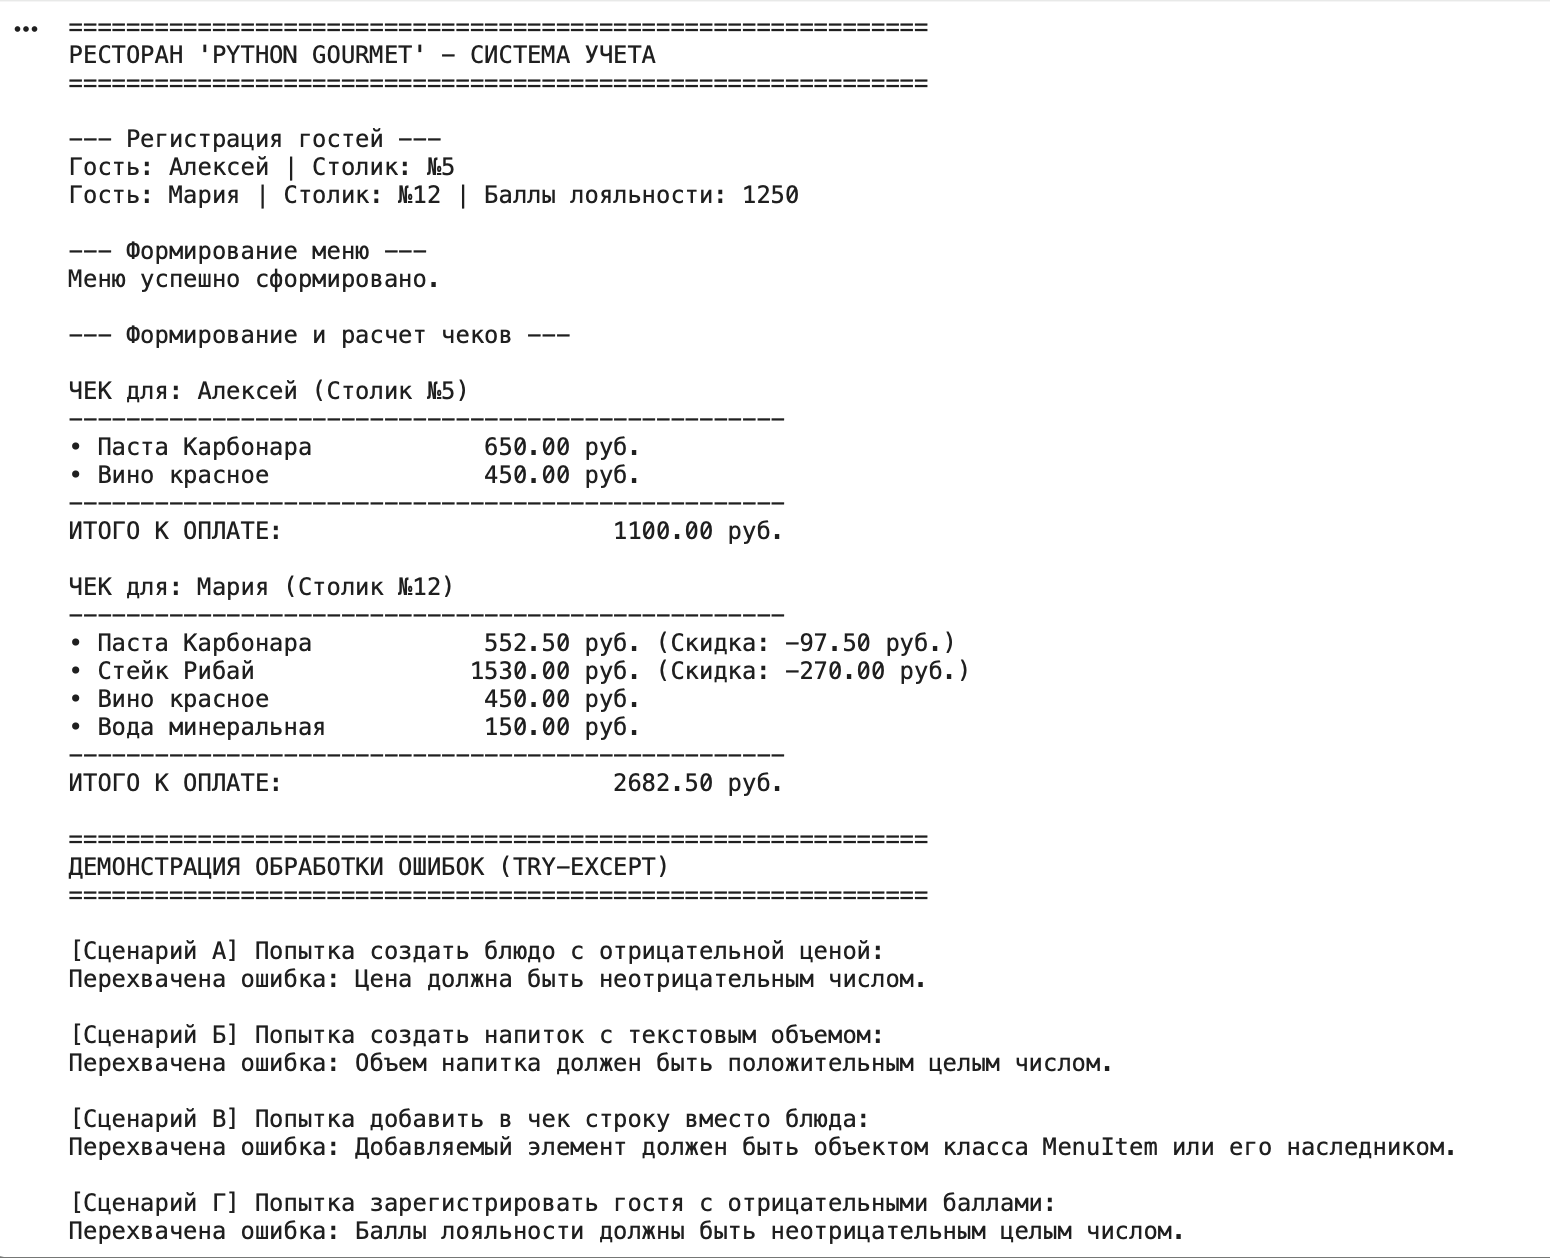